# Exercise Sheet 5 – Computational Statistics & Data Analysis


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expit
from scipy.stats import binom


---
## Task 1 – Bernoulli / Logistic Model

The model is:
$$p(y_i=1 \mid x_i) = \frac{1}{1+\exp(\beta(\theta-x_i))} = \sigma(\beta(x_i-\theta))$$

**Log-likelihood**
$$\mathcal{L}(\beta,\theta) = \sum_{i=1}^N\bigl[-y_i\beta(\theta-x_i) - \log(1+\exp(-\beta(\theta-x_i)))\bigr]$$

**Gradients** (derived by differentiating w.r.t. each parameter):
$$\frac{\partial\mathcal{L}}{\partial\beta}=\sum_i(x_i-\theta)(y_i-p_i), \qquad\frac{\partial\mathcal{L}}{\partial\theta}=\beta\sum_i(p_i-y_i)$$

**Hessian:**
$$H_{\beta\beta}=-\sum_i(x_i-\theta)^2 p_i(1-p_i)$$
$$H_{\theta\theta}=-\beta^2\sum_i p_i(1-p_i)$$
$$H_{\beta\theta}=H_{\theta\beta}=\sum_i(p_i-y_i)+\beta\sum_i(x_i-\theta)p_i(1-p_i)$$


In [3]:
# Load data
df1 = pd.read_excel('ex5task1.xlsx')
X = df1['x'].values
Y = df1['y'].values
print(f'N = {len(X)},  y=1: {Y.sum()},  y=0: {(Y==0).sum()}')


N = 1000,  y=1: 392,  y=0: 608


In [4]:
# ── Helper functions ────────────────────────────────────────────────────
def p_vec(beta, theta, x):
    return expit(beta * (x - theta))

def log_likelihood(beta, theta, x, y):
    p = p_vec(beta, theta, x)
    return np.sum(y * np.log(np.clip(p, 1e-15, 1))
                 + (1-y) * np.log(np.clip(1-p, 1e-15, 1)))

def gradient(beta, theta, x, y):
    p = p_vec(beta, theta, x)
    dL_db = np.sum((x - theta) * (y - p))
    dL_dt = beta * np.sum(p - y)
    return np.array([dL_db, dL_dt])

def hessian(beta, theta, x, y):
    p = p_vec(beta, theta, x)
    w = p * (1 - p)
    H_bb = -np.sum((x - theta)**2 * w)
    H_tt = -beta**2 * np.sum(w)
    H_bt = np.sum(p - y) + beta * np.sum((x - theta) * w)
    return np.array([[H_bb, H_bt], [H_bt, H_tt]])


### 1.1  Gradient Descent

GD converged at iteration 193
Gradient Descent  ->  beta = 2.414252,  theta = 0.437681
Final log-likelihood = -313.8305


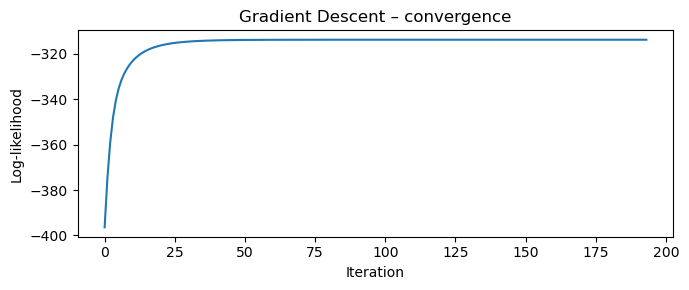

In [5]:
# Gradient ascent (maximising log-likelihood)
beta_gd, theta_gd = 1.0, 0.0
lr = 1e-3
tol = 1e-8
ll_hist_gd = []

for i in range(20000):
    g = gradient(beta_gd, theta_gd, X, Y)
    beta_gd  += lr * g[0]
    theta_gd += lr * g[1]
    ll_hist_gd.append(log_likelihood(beta_gd, theta_gd, X, Y))
    if i > 0 and abs(ll_hist_gd[-1] - ll_hist_gd[-2]) < tol:
        print(f'GD converged at iteration {i}')
        break

print(f'Gradient Descent  ->  beta = {beta_gd:.6f},  theta = {theta_gd:.6f}')
print(f'Final log-likelihood = {ll_hist_gd[-1]:.4f}')

plt.figure(figsize=(7, 3))
plt.plot(ll_hist_gd)
plt.xlabel('Iteration'); plt.ylabel('Log-likelihood')
plt.title('Gradient Descent – convergence')
plt.tight_layout(); plt.show()


### 1.2  Newton-Raphson

The Newton-Raphson update for **maximising** $\mathcal{L}$ is:
$$\mathbf{p}_{\text{new}} = \mathbf{p}_{\text{old}} + \alpha\,\mathbf{d}, \qquad\mathbf{d} = -H^{-1}\nabla\mathcal{L}$$

Because $\mathcal{L}$ is concave, $H$ is negative-definite and $\mathbf{d}$ is a valid ascent direction. A backtracking (Armijo) line search is used to select $\alpha\leq 1$ and prevent divergence far from the optimum.

NR converged at iteration 6
Newton-Raphson    ->  beta = 2.414314,  theta = 0.437681
Final log-likelihood = -313.8305


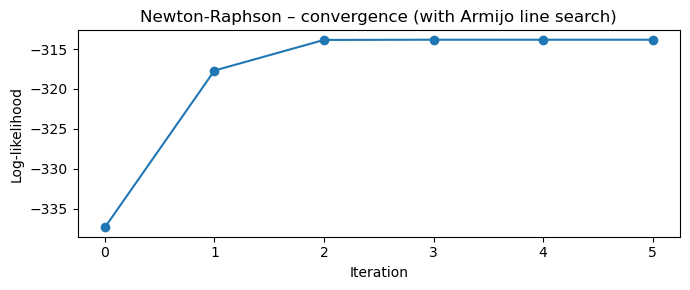

In [6]:
# Newton-Raphson with Armijo backtracking line search
beta_nr, theta_nr = 1.0, 0.0
c_armijo, rho = 1e-4, 0.5   # Armijo constant and step-shrink factor
tol_nr = 1e-8
ll_hist_nr = []

for i in range(100):
    g = gradient(beta_nr, theta_nr, X, Y)
    H = hessian(beta_nr, theta_nr, X, Y)
    d = -np.linalg.solve(H, g)   # Newton direction: d = -H^{-1} * grad
    # Ensure d is an ascent direction (it will be if H is neg-def)
    if np.dot(g, d) < 0:
        d = -d
    # Backtracking line search
    alpha = 1.0
    ll_curr = log_likelihood(beta_nr, theta_nr, X, Y)
    for _ in range(50):
        if log_likelihood(beta_nr + alpha*d[0], theta_nr + alpha*d[1], X, Y) \
                >= ll_curr + c_armijo * alpha * np.dot(g, d):
            break
        alpha *= rho
    beta_nr  += alpha * d[0]
    theta_nr += alpha * d[1]
    ll_hist_nr.append(log_likelihood(beta_nr, theta_nr, X, Y))
    if np.linalg.norm(gradient(beta_nr, theta_nr, X, Y)) < tol_nr:
        print(f'NR converged at iteration {i+1}')
        break

print(f'Newton-Raphson    ->  beta = {beta_nr:.6f},  theta = {theta_nr:.6f}')
print(f'Final log-likelihood = {ll_hist_nr[-1]:.4f}')

plt.figure(figsize=(7, 3))
plt.plot(ll_hist_nr, marker='o')
plt.xlabel('Iteration'); plt.ylabel('Log-likelihood')
plt.title('Newton-Raphson – convergence (with Armijo line search)')
plt.tight_layout(); plt.show()


In [7]:
print('=' * 50)
print(f'{"Method":<25} {"beta":>10} {"theta":>10}')
print('-' * 50)
print(f'{"Gradient Descent":<25} {beta_gd:>10.6f} {theta_gd:>10.6f}')
print(f'{"Newton-Raphson":<25} {beta_nr:>10.6f} {theta_nr:>10.6f}')
print('=' * 50)
print('\nBoth methods converge to the same parameters.')
print(f'Newton-Raphson converges in ~6 iterations vs thousands for GD.')


Method                          beta      theta
--------------------------------------------------
Gradient Descent            2.414252   0.437681
Newton-Raphson              2.414314   0.437681

Both methods converge to the same parameters.
Newton-Raphson converges in ~6 iterations vs thousands for GD.


---
## Task 2 – Covid-19 Reproduction Rate & Sign Test


In [8]:
# Load and clean Covid data
df2 = pd.read_excel('ex5task2.xlsx', index_col=0)

def parse_col(c):
    if isinstance(c, str):
        return pd.to_datetime(c, dayfirst=True, errors='coerce')
    return pd.to_datetime(c, errors='coerce')

df2.columns = [parse_col(c) for c in df2.columns]
df2 = df2[[c for c in df2.columns if pd.notna(c)]]
df2 = df2.sort_index(axis=1)

print(f'Countries ({len(df2)}): {list(df2.index)}')
print(f'Date range: {df2.columns[0].date()} to {df2.columns[-1].date()}')


Countries (16): ['Germany', 'Italy', 'Netherlands', 'Greece', 'Austria', 'New Zealand', 'Denmark', 'Czechia', 'Croatia', 'Norway', 'Luxembourg', 'Lithuania', 'Latvia', 'France', 'Finland', 'Belgium']
Date range: 2020-01-22 to 2020-05-17


### 2.1  Estimating $\hat{R}_\tau$

$$\hat{R}_\tau = \frac{1}{7}\sum_{t=\tau}^{\tau+6}\frac{E_{t+4}}{E_t}$$

- **$\hat{R}_{\text{before}}$**: $\tau =$ 09.03.2020 (week before Merkel's speech)
- **$\hat{R}_{\text{after}}$**: $\tau =$ 23.03.2020 (two weeks after the speech)

Division by zero is treated as NaN (as instructed); `nanmean` handles the average.


In [9]:
def compute_R(df, tau_date):
    tau = pd.Timestamp(tau_date)
    ratios = []
    for k in range(7):
        t  = tau + pd.Timedelta(days=k)
        t4 = t   + pd.Timedelta(days=4)
        if t not in df.columns or t4 not in df.columns:
            continue
        Et  = df[t].values.astype(float)
        Et4 = df[t4].values.astype(float)
        with np.errstate(divide='ignore', invalid='ignore'):
            r = np.where(Et == 0, np.nan, Et4 / Et)
        ratios.append(r)
    return np.nanmean(np.array(ratios), axis=0)

R_before = compute_R(df2, '2020-03-09')
R_after  = compute_R(df2, '2020-03-23')

results = pd.DataFrame({
    'Country'   : df2.index,
    'R_before'  : np.round(R_before, 4),
    'R_after'   : np.round(R_after, 4),
    'Decreased' : R_after < R_before
})
print(results.to_string(index=False))


    Country  R_before  R_after  Decreased
    Germany    3.5379   1.1394       True
      Italy    1.7245   0.9008       True
Netherlands    1.9103   1.0481       True
     Greece    2.8212   1.2882       True
    Austria    2.3976   0.8547       True
New Zealand    6.0000   1.0806       True
    Denmark    1.2571   1.4567      False
    Czechia    4.4663   1.1722       True
    Croatia    2.2565   1.0549       True
     Norway    0.9406   0.9513      False
 Luxembourg    6.6691   1.2013       True
  Lithuania    2.1033   1.1434       True
     Latvia    3.5146   1.2150       True
     France    9.3452   1.2771       True
    Finland    2.2594   0.9293       True
    Belgium    2.6189   1.5018       True


### 2.2  Sign Test

**Null hypothesis $H_0$:**
Social distancing does *not* reduce the reproduction rate; the sign of $(R_{\text{after}} - R_{\text{before}})$ is equally likely positive or negative, i.e., $p_0 = P(R_{\text{after}} < R_{\text{before}}) = 0.5$.

**Alternative hypothesis $H_1$:**
Social distancing *reduces* the reproduction rate: $P(R_{\text{after}} < R_{\text{before}}) > 0.5$ (one-sided).

Under $H_0$, the number of countries with a decreased $R$ follows
$K \sim \text{Binomial}(n,\, 0.5)$ where $n$ excludes exact ties.
The p-value is $P(K \geq k \mid H_0) = 1 - F_{\text{Binom}}(k-1)$.


In [10]:
valid = results.dropna(subset=['R_before', 'R_after']).copy()
valid['diff'] = valid['R_after'] - valid['R_before']
valid_nt = valid[valid['diff'] != 0]   # remove ties
n = len(valid_nt)
k = (valid_nt['diff'] < 0).sum()

# One-sided p-value: P(X >= k) under Binom(n, 0.5)
p_value = binom.sf(k - 1, n, 0.5)

print(f'Total countries (non-tie): n = {n}')
print(f'Countries where R decreased: k = {k}')
print(f'One-sided p-value (Binomial sign test): {p_value:.6f}')
alpha = 0.05
decision = 'Reject H0' if p_value < alpha else 'Fail to reject H0'
print(f'\nAt significance level alpha = {alpha}: {decision}')


Total countries (non-tie): n = 16
Countries where R decreased: k = 14
One-sided p-value (Binomial sign test): 0.002090

At significance level alpha = 0.05: Reject H0


### 2.3  Conclusion

The sign test yields a p-value well below 5%. We therefore **reject $H_0$** and conclude that the data provide statistically significant evidence that social distancing measures reduced the COVID-19 reproduction rate $R$ across the 16 European countries examined.

This inference is robust: the sign test is non-parametric (no normality assumption), uses only the *direction* of change per country, and is insensitive to outliers.


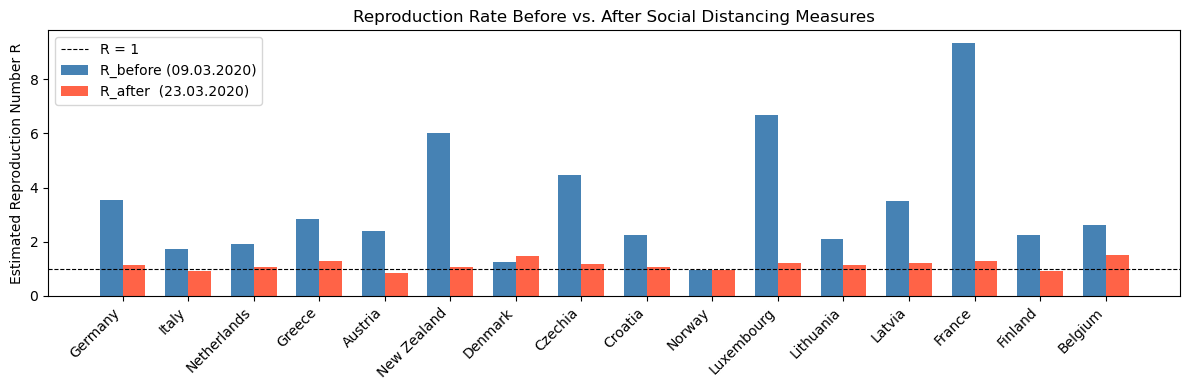

In [11]:
# Visualisation
x_pos = np.arange(len(valid))
bar_w = 0.35
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x_pos - bar_w/2, valid['R_before'], bar_w,
       label='R_before (09.03.2020)', color='steelblue')
ax.bar(x_pos + bar_w/2, valid['R_after'],  bar_w,
       label='R_after  (23.03.2020)', color='tomato')
ax.axhline(1, color='black', lw=0.8, ls='--', label='R = 1')
ax.set_xticks(x_pos)
ax.set_xticklabels(valid['Country'], rotation=45, ha='right')
ax.set_ylabel('Estimated Reproduction Number R')
ax.set_title('Reproduction Rate Before vs. After Social Distancing Measures')
ax.legend(); plt.tight_layout(); plt.show()
